# Colonia de Hormigas: Ruta Más Corta
## Problema de Reemplazo de Automóviles en 4 Años

**Problema:** RentCar necesita optimizar su política de reemplazo de automóviles en un horizonte de 4 años.

**Enfoques de solución:**
1. Programación Lineal (Método Simplex) - Solución óptima determinista
2. Ant Colony Optimization - Metaheurística inspirada en hormigas

## 1. Planteamiento del Problema

### Descripción

RentCar está desarrollando una política de reemplazo para su flotilla de automóviles en un horizonte de planeación de 4 años. 

**Reglas:**
- Al inicio de cada año, un automóvil se reemplaza o se conserva en operación
- Un automóvil debe estar en servicio de 1 a 3 años
- Se busca minimizar el costo total de reemplazo

### Tabla de Costos de Reemplazo

| Año de Compra | 1 año de uso | 2 años de uso | 3 años de uso |
|---------------|--------------|---------------|---------------|
| 1             | 4,000        | 5,400         | 9,800         |
| 2             | 4,300        | 6,200         | 8,700         |
| 3             | 4,800        | 7,100         | —             |
| 4             | 4,900        | —             | —             |

In [14]:
# Importar librerías
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog
import pandas as pd

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [15]:
# Definir datos del problema
costos_tabla = {
    1: {1: 4000, 2: 5400, 3: 9800},
    2: {1: 4300, 2: 6200, 3: 8700},
    3: {1: 4800, 2: 7100},
    4: {1: 4900}
}

# Crear grafo para visualización
grafo = {}
for i in range(5):
    grafo[i] = {}

for año_compra in costos_tabla:
    nodo_origen = año_compra - 1
    for años_uso, costo in costos_tabla[año_compra].items():
        nodo_destino = nodo_origen + años_uso
        if nodo_destino <= 4:
            grafo[nodo_origen][nodo_destino] = costo

print("GRAFO DEL PROBLEMA\n")
for nodo in sorted(grafo.keys()):
    if grafo[nodo]:
        print(f"Nodo {nodo}:")
        for destino, costo in sorted(grafo[nodo].items()):
            años = destino - nodo
            print(f"  -> Nodo {destino}: {años} año(s) = ${costo:,}")

GRAFO DEL PROBLEMA

Nodo 0:
  -> Nodo 1: 1 año(s) = $4,000
  -> Nodo 2: 2 año(s) = $5,400
  -> Nodo 3: 3 año(s) = $9,800
Nodo 1:
  -> Nodo 2: 1 año(s) = $4,300
  -> Nodo 3: 2 año(s) = $6,200
  -> Nodo 4: 3 año(s) = $8,700
Nodo 2:
  -> Nodo 3: 1 año(s) = $4,800
  -> Nodo 4: 2 año(s) = $7,100
Nodo 3:
  -> Nodo 4: 1 año(s) = $4,900


## 2. Modelo Matemático - Programación Lineal

### Formulación como Problema de Flujo de Costo Mínimo

Este problema puede modelarse como un **problema de camino más corto** o **flujo de costo mínimo** en una red.

### Variables de Decisión

Definimos variables binarias $x_{ij}$ para cada arista del grafo:

$$
x_{ij} = \begin{cases}
1 & \text{si se utiliza la arista del nodo } i \text{ al nodo } j \\
0 & \text{en caso contrario}
\end{cases}
$$

**Aristas disponibles:**
- $x_{01}$: Año 1, usar 1 año (costo 4,000)
- $x_{02}$: Año 1, usar 2 años (costo 5,400)
- $x_{03}$: Año 1, usar 3 años (costo 9,800)
- $x_{12}$: Año 2, usar 1 año (costo 4,300)
- $x_{13}$: Año 2, usar 2 años (costo 6,200)
- $x_{14}$: Año 2, usar 3 años (costo 8,700)
- $x_{23}$: Año 3, usar 1 año (costo 4,800)
- $x_{24}$: Año 3, usar 2 años (costo 7,100)
- $x_{34}$: Año 4, usar 1 año (costo 4,900)

### Función Objetivo

Minimizar el costo total:

$$
\min Z = 4000x_{01} + 5400x_{02} + 9800x_{03} + 4300x_{12} + 6200x_{13} + 8700x_{14} + 4800x_{23} + 7100x_{24} + 4900x_{34}
$$

### Restricciones

**1. Conservación de flujo en cada nodo:**

El flujo que entra debe ser igual al flujo que sale (excepto en origen y destino).

**Nodo 0 (origen):**
$$
x_{01} + x_{02} + x_{03} = 1
$$

**Nodo 1:**
$$
x_{01} - (x_{12} + x_{13} + x_{14}) = 0
$$
o equivalentemente:
$$
x_{01} = x_{12} + x_{13} + x_{14}
$$

**Nodo 2:**
$$
x_{02} + x_{12} - (x_{23} + x_{24}) = 0
$$

**Nodo 3:**
$$
x_{03} + x_{13} + x_{23} - x_{34} = 0
$$

**Nodo 4 (destino):**
$$
x_{14} + x_{24} + x_{34} = 1
$$

**2. Restricciones de no negatividad y binaridad:**
$$
x_{ij} \in \{0, 1\} \quad \forall (i,j)
$$

Para el método Simplex, podemos relajar a:
$$
0 \leq x_{ij} \leq 1 \quad \forall (i,j)
$$

Debido a la estructura del problema (camino más corto), la solución será automáticamente entera.

### Modelo Completo en Forma Estándar

$$
\begin{align*}
\min \quad & Z = 4000x_{01} + 5400x_{02} + 9800x_{03} + 4300x_{12} + 6200x_{13} + 8700x_{14} + 4800x_{23} + 7100x_{24} + 4900x_{34} \\
\text{s.a.} \quad & x_{01} + x_{02} + x_{03} = 1 \\
& x_{01} - x_{12} - x_{13} - x_{14} = 0 \\
& x_{02} + x_{12} - x_{23} - x_{24} = 0 \\
& x_{03} + x_{13} + x_{23} - x_{34} = 0 \\
& x_{14} + x_{24} + x_{34} = 1 \\
& x_{ij} \geq 0 \quad \forall (i,j)
\end{align*}
$$

### Implementación del Modelo con Scipy (Método Simplex)

In [16]:
# Definir el problema de programación lineal

# Coeficientes de la función objetivo (costos)
# Orden: x01, x02, x03, x12, x13, x14, x23, x24, x34
import time


tiempo_modelo_matematico = time.time()
c = [4000, 5400, 9800, 4300, 6200, 8700, 4800, 7100, 4900]

# Matriz de restricciones de igualdad (Ax = b)
# Cada fila representa una restricción de conservación de flujo

# Variables: x01  x02  x03  x12  x13  x14  x23  x24  x34
A_eq = [
    [  1,   1,   1,   0,   0,   0,   0,   0,   0],  # Nodo 0: salida
    [  1,   0,   0,  -1,  -1,  -1,   0,   0,   0],  # Nodo 1: entrada - salida = 0
    [  0,   1,   0,   1,   0,   0,  -1,  -1,   0],  # Nodo 2: entrada - salida = 0
    [  0,   0,   1,   0,   1,   0,   1,   0,  -1],  # Nodo 3: entrada - salida = 0
    [  0,   0,   0,   0,   0,   1,   0,   1,   1],  # Nodo 4: entrada
]

b_eq = [1, 0, 0, 0, 1]

# Límites para las variables: 0 <= x_ij <= 1
bounds = [(0, 1) for _ in range(9)]

# Resolver usando el método simplex
print("\nResolviendo con Método Simplex...\n")
resultado = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if resultado.success:
    print("SOLUCIÓN ÓPTIMA ENCONTRADA\n")
    print(f"Costo mínimo: ${resultado.fun:,.2f}\n")
    
    # Mostrar valores de las variables
    nombres_var = ['x01', 'x02', 'x03', 'x12', 'x13', 'x14', 'x23', 'x24', 'x34']
    aristas_info = [
        ('x01', 0, 1, 1, 4000),
        ('x02', 0, 2, 2, 5400),
        ('x03', 0, 3, 3, 9800),
        ('x12', 1, 2, 1, 4300),
        ('x13', 1, 3, 2, 6200),
        ('x14', 1, 4, 3, 8700),
        ('x23', 2, 3, 1, 4800),
        ('x24', 2, 4, 2, 7100),
        ('x34', 3, 4, 1, 4900)
    ]
    
    print("Valores de las variables de decisión:\n")
    print(f"{'Variable':<8} {'Valor':<8} {'Arista':<10} {'Años uso':<10} {'Costo':<10}")
    print("-" * 60)
    
    camino_solucion = []
    for i, (var, origen, destino, años, costo) in enumerate(aristas_info):
        valor = resultado.x[i]
        estado = "USADO" if valor > 0.5 else ""
        print(f"{var:<8} {valor:>7.4f}  {origen}->{destino:<8} {años:<10} ${costo:<9,} {estado}")
        
        if valor > 0.5:  # Variable usada en la solución
            camino_solucion.append((origen, destino, años, costo))
    
    # Reconstruir el camino
    camino_solucion.sort(key=lambda x: x[0])
    nodos_camino = [0]
    for origen, destino, _, _ in camino_solucion:
        nodos_camino.append(destino)
    
    print(f"\nCamino óptimo: {nodos_camino}")
    print("\nPlan de reemplazo:")
    for origen, destino, años, costo in camino_solucion:
        año_compra = origen + 1
        print(f"  Año {año_compra}: Comprar auto y usarlo {años} año(s) -> Costo: ${costo:,}")

    tiempo_modelo_matematico = time.time() - tiempo_modelo_matematico
    print(f"\nTiempo de resolución del modelo matemático: {tiempo_modelo_matematico:.6f} segundos")
    
else:
    print("No se encontró solución óptima")
    print(f"Mensaje: {resultado.message}")


Resolviendo con Método Simplex...

SOLUCIÓN ÓPTIMA ENCONTRADA

Costo mínimo: $12,500.00

Valores de las variables de decisión:

Variable Valor    Arista     Años uso   Costo     
------------------------------------------------------------
x01      -0.0000  0->1        1          $4,000     
x02       1.0000  0->2        2          $5,400     USADO
x03       0.0000  0->3        3          $9,800     
x12       0.0000  1->2        1          $4,300     
x13       0.0000  1->3        2          $6,200     
x14       0.0000  1->4        3          $8,700     
x23       0.0000  2->3        1          $4,800     
x24       1.0000  2->4        2          $7,100     USADO
x34      -0.0000  3->4        1          $4,900     

Camino óptimo: [0, 2, 4]

Plan de reemplazo:
  Año 1: Comprar auto y usarlo 2 año(s) -> Costo: $5,400
  Año 3: Comprar auto y usarlo 2 año(s) -> Costo: $7,100

Tiempo de resolución del modelo matemático: 0.002414 segundos


### Interpretación del Modelo

El modelo de Programación Lineal resuelve el problema como un **problema de flujo de red**:

**Concepto:** Enviar una unidad de flujo desde el nodo origen (0) hasta el nodo destino (4) con costo mínimo.

**Variables binarias:** Cada $x_{ij}$ indica si se usa o no la arista $(i,j)$

**Conservación de flujo:** Lo que entra a un nodo debe salir (excepto origen y destino)

**Ventajas del método:**
- Garantiza solución óptima
- Eficiente (algoritmo Simplex)
- Solución automáticamente entera para este tipo de problema
- Bien fundamentado matemáticamente

## 3. Solución por Ant Colony Optimization

### Fundamento del Algoritmo ACO

ACO es un algoritmo metaheurístico inspirado en el comportamiento de las hormigas reales:

**Mecanismo:**
1. Las hormigas construyen soluciones de forma probabilística
2. Depositan feromonas en los caminos que recorren
3. Caminos mejores acumulan más feromonas
4. La evaporación evita convergencia prematura
5. Proceso iterativo hasta convergencia

### Formulación Matemática

**Parámetros:**
- $\alpha$ = importancia de las feromonas (típicamente 1)
- $\beta$ = importancia de la heurística (típicamente 1-5)
- $\rho$ = tasa de evaporación (típicamente 0.1-0.5)
- $Q$ = cantidad de feromonas a depositar
- $m$ = número de hormigas

**Probabilidad de transición:**

La hormiga $k$ en el nodo $i$ selecciona el nodo $j$ con probabilidad:

$$
P^k_{ij} = \frac{[\tau_{ij}]^\alpha \cdot [\eta_{ij}]^\beta}{\sum_{l \in N_i} [\tau_{il}]^\alpha \cdot [\eta_{il}]^\beta}
$$

donde:
- $\tau_{ij}$ = nivel de feromonas en la arista $(i,j)$
- $\eta_{ij} = \frac{1}{c_{ij}}$ = heurística (inversamente proporcional al costo)
- $N_i$ = conjunto de nodos vecinos de $i$

**Actualización de feromonas:**

Al final de cada iteración:

1. **Evaporación:**
$$
\tau_{ij} \leftarrow (1-\rho) \cdot \tau_{ij} \quad \forall (i,j)
$$

2. **Depósito por cada hormiga:**
$$
\tau_{ij} \leftarrow \tau_{ij} + \sum_{k=1}^{m} \Delta\tau^k_{ij}
$$

donde:
$$
\Delta\tau^k_{ij} = \begin{cases}
\frac{Q}{L_k} & \text{si la hormiga } k \text{ usó la arista } (i,j) \\
0 & \text{en caso contrario}
\end{cases}
$$

y $L_k$ = costo total del camino de la hormiga $k$

3. **Refuerzo elitista (opcional):**
$$
\tau_{ij} \leftarrow \tau_{ij} + \frac{Q}{L_{best}} \quad \forall (i,j) \in \text{mejor camino global}
$$

donde $L_{best}$ = costo del mejor camino encontrado hasta el momento

In [17]:
# Configurar parámetros ACO
random.seed(0)
np.random.seed(0)

alpha = 1
beta = 1
rho = 0.1
Q = 10000
num_hormigas = 4
num_iteraciones = 100

# Inicializar feromonas
feromonas = {}
for i in grafo:
    feromonas[i] = {}
    for j in grafo[i]:
        feromonas[i][j] = 0.1

print("PARÁMETROS DEL ALGORITMO ACO\n")
print(f"alpha (α) - Peso de feromonas:           {alpha}")
print(f"beta (β)  - Peso de heurística:          {beta}")
print(f"rho (ρ)   - Tasa de evaporación:         {rho}")
print(f"Q         - Constante de depósito:       {Q}")
print(f"m         - Número de hormigas:          {num_hormigas}")
print(f"          - Iteraciones:                 {num_iteraciones}")
print(f"          - Feromonas iniciales:         0.1")

PARÁMETROS DEL ALGORITMO ACO

alpha (α) - Peso de feromonas:           1
beta (β)  - Peso de heurística:          1
rho (ρ)   - Tasa de evaporación:         0.1
Q         - Constante de depósito:       10000
m         - Número de hormigas:          4
          - Iteraciones:                 100
          - Feromonas iniciales:         0.1


In [27]:
def calcular_costo_camino(camino):
    """Calcula el costo total de un camino"""
    costo = 0
    for i in range(len(camino) - 1):
        costo += grafo[camino[i]][camino[i+1]]
    return costo

def construir_camino_hormiga():
    """
    Una hormiga construye un camino del nodo 0 al 4
    usando probabilidades basadas en feromonas y heurística
    """
    camino = [0]
    nodo_actual = 0
    
    while nodo_actual != 4:
        vecinos = list(grafo[nodo_actual].keys())
        if not vecinos:
            return None
        
        # Calcular probabilidades según fórmula ACO
        probabilidades = []
        suma_total = 0
        
        for vecino in vecinos:
            feromona = feromonas[nodo_actual][vecino] ** alpha
            heuristica = (1.0 / grafo[nodo_actual][vecino]) ** beta
            valor = feromona * heuristica
            probabilidades.append(valor)
            suma_total += valor
        
        # Normalizar probabilidades
        probabilidades = [p / suma_total for p in probabilidades]
        
        # Seleccionar siguiente nodo
        siguiente_nodo = np.random.choice(vecinos, p=probabilidades)
        camino.append(siguiente_nodo)
        nodo_actual = siguiente_nodo
    
    return camino

# Variables para rastrear resultados
mejor_camino_aco = None
mejor_costo_aco = float('inf')
historial_mejor = []
historial_promedio = []

print("\nEjecutando Ant Colony Optimization...\n")

tiempo_modelo_hormigas = time.time()


for iteracion in range(num_iteraciones):
    caminos_iter = []
    costos_iter = []
    
    # Cada hormiga construye un camino
    for k in range(num_hormigas):
        camino = construir_camino_hormiga()
        if camino:
            costo = calcular_costo_camino(camino)
            caminos_iter.append(camino)
            costos_iter.append(costo)
    
    if costos_iter:
        mejor_idx = np.argmin(costos_iter)
        mejor_camino_iter = caminos_iter[mejor_idx]
        mejor_costo_iter = costos_iter[mejor_idx]
        
        historial_mejor.append(mejor_costo_aco if mejor_costo_aco != float('inf') else mejor_costo_iter)
        historial_promedio.append(np.mean(costos_iter))
        
        if mejor_costo_iter < mejor_costo_aco:
            mejor_costo_aco = mejor_costo_iter
            mejor_camino_aco = mejor_camino_iter
            print(f"  Iteración {iteracion+1:3d}: Nueva mejor solución -> ${mejor_costo_aco:,}")
    
    # Evaporación de feromonas
    for i in feromonas:
        for j in feromonas[i]:
            feromonas[i][j] *= (1 - rho)
    
    # Depósito de feromonas por cada hormiga
    for k in range(len(caminos_iter)):
        camino = caminos_iter[k]
        costo = costos_iter[k]
        delta = Q / costo
        for i in range(len(camino) - 1):
            feromonas[camino[i]][camino[i+1]] += delta
    
    # Refuerzo elitista
    if mejor_camino_aco:
        delta_elite = Q / mejor_costo_aco
        for i in range(len(mejor_camino_aco) - 1):
            feromonas[mejor_camino_aco[i]][mejor_camino_aco[i+1]] += delta_elite

tiempo_modelo_hormigas =  time.time() - tiempo_modelo_hormigas
print("\nAlgoritmo ACO completado.")
print(f"\nTiempo de resolución del algoritmo de hormiga: {tiempo_modelo_hormigas:.6f} segundos")



Ejecutando Ant Colony Optimization...

  Iteración   1: Nueva mejor solución -> $12,500

Algoritmo ACO completado.

Tiempo de resolución del algoritmo de hormiga: 0.012440 segundos


In [19]:
print("\nRESULTADO - ANT COLONY OPTIMIZATION\n")
print(f"Camino encontrado: {mejor_camino_aco}")
print(f"Costo: ${mejor_costo_aco:,}\n")
print("Plan de reemplazo:")
for i in range(len(mejor_camino_aco) - 1):
    año = mejor_camino_aco[i] + 1
    años_uso = mejor_camino_aco[i+1] - mejor_camino_aco[i]
    costo = grafo[mejor_camino_aco[i]][mejor_camino_aco[i+1]]
    print(f"  Año {año}: Comprar auto y usarlo {años_uso} año(s) -> Costo: ${costo:,}")


RESULTADO - ANT COLONY OPTIMIZATION

Camino encontrado: [0, np.int64(2), np.int64(4)]
Costo: $12,500

Plan de reemplazo:
  Año 1: Comprar auto y usarlo 2 año(s) -> Costo: $5,400
  Año 3: Comprar auto y usarlo 2 año(s) -> Costo: $7,100


### Análisis de la Última Iteración ACO

In [20]:
print("\nÚLTIMA ITERACIÓN - CAMINOS DE LAS 4 HORMIGAS\n")

caminos_finales = []
costos_finales = []

for k in range(4):
    camino = construir_camino_hormiga()
    if camino:
        costo = calcular_costo_camino(camino)
        caminos_finales.append(camino)
        costos_finales.append(costo)
        print(f"Hormiga {k+1}:")
        print(f"  Camino: {camino}")
        print(f"  Costo: ${costo:,}")
        print(f"  Decisiones:")
        for i in range(len(camino) - 1):
            año = camino[i] + 1
            años_uso = camino[i+1] - camino[i]
            costo_seg = grafo[camino[i]][camino[i+1]]
            print(f"    Año {año}: usar {años_uso} año(s) -> ${costo_seg:,}")
        print()


ÚLTIMA ITERACIÓN - CAMINOS DE LAS 4 HORMIGAS

Hormiga 1:
  Camino: [0, np.int64(2), np.int64(4)]
  Costo: $12,500
  Decisiones:
    Año 1: usar 2 año(s) -> $5,400
    Año 3: usar 2 año(s) -> $7,100

Hormiga 2:
  Camino: [0, np.int64(2), np.int64(4)]
  Costo: $12,500
  Decisiones:
    Año 1: usar 2 año(s) -> $5,400
    Año 3: usar 2 año(s) -> $7,100

Hormiga 3:
  Camino: [0, np.int64(2), np.int64(3), np.int64(4)]
  Costo: $15,100
  Decisiones:
    Año 1: usar 2 año(s) -> $5,400
    Año 3: usar 1 año(s) -> $4,800
    Año 4: usar 1 año(s) -> $4,900

Hormiga 4:
  Camino: [0, np.int64(2), np.int64(4)]
  Costo: $12,500
  Decisiones:
    Año 1: usar 2 año(s) -> $5,400
    Año 3: usar 2 año(s) -> $7,100



### Matriz de Feromonas Finales (τ^k_{i,j})

In [21]:
print("\nMATRIZ DE FEROMONAS FINALES (tau_ij)\n")
print(f"{'Arista (i->j)':<15} {'tau_ij':<15} {'Interpretación'}")
print("-" * 70)

feromonas_list = []
for i in sorted(feromonas.keys()):
    for j in sorted(feromonas[i].keys()):
        feromonas_list.append((i, j, feromonas[i][j]))

feromonas_list.sort(key=lambda x: x[2], reverse=True)

for i, j, valor in feromonas_list:
    if valor > 10:
        interp = "RUTA ÓPTIMA (alta feromona)"
    elif valor > 1:
        interp = "Ruta subóptima"
    else:
        interp = "Ruta poco utilizada"
    print(f"{i}->{j:<13} {valor:<15.6f} {interp}")


MATRIZ DE FEROMONAS FINALES (tau_ij)

Arista (i->j)   tau_ij          Interpretación
----------------------------------------------------------------------
0->2             39.537378       RUTA ÓPTIMA (alta feromona)
2->4             37.319072       RUTA ÓPTIMA (alta feromona)
3->4             2.218440        Ruta subóptima
2->3             2.218308        Ruta subóptima
0->3             0.000134        Ruta poco utilizada
0->1             0.000003        Ruta poco utilizada
1->2             0.000003        Ruta poco utilizada
1->3             0.000003        Ruta poco utilizada
1->4             0.000003        Ruta poco utilizada


## 4. Comparación de Resultados

### Todos los Caminos Posibles (Enumeración Exhaustiva)

In [22]:
def encontrar_todos_caminos(nodo_actual, nodo_destino, camino_actual, todos_caminos):
    """Encuentra todos los caminos posibles mediante backtracking"""
    if nodo_actual == nodo_destino:
        todos_caminos.append(camino_actual[:])
        return
    
    for vecino in grafo[nodo_actual]:
        camino_actual.append(vecino)
        encontrar_todos_caminos(vecino, nodo_destino, camino_actual, todos_caminos)
        camino_actual.pop()

todos_caminos = []
encontrar_todos_caminos(0, 4, [0], todos_caminos)

print("\nENUMERACIÓN EXHAUSTIVA - TODOS LOS CAMINOS POSIBLES\n")
print(f"Total de caminos: {len(todos_caminos)}\n")

caminos_con_costos = [(c, calcular_costo_camino(c)) for c in todos_caminos]
caminos_con_costos.sort(key=lambda x: x[1])

print(f"{'#':<4} {'Camino':<25} {'Costo':<12} {'Observación'}")
print("-" * 70)
for i, (camino, costo) in enumerate(caminos_con_costos, 1):
    obs = "<- ÓPTIMO" if costo == min(c for _, c in caminos_con_costos) else ""
    print(f"{i:<4} {str(camino):<25} ${costo:<11,} {obs}")


ENUMERACIÓN EXHAUSTIVA - TODOS LOS CAMINOS POSIBLES

Total de caminos: 7

#    Camino                    Costo        Observación
----------------------------------------------------------------------
1    [0, 2, 4]                 $12,500      <- ÓPTIMO
2    [0, 1, 4]                 $12,700      
3    [0, 3, 4]                 $14,700      
4    [0, 1, 3, 4]              $15,100      
5    [0, 2, 3, 4]              $15,100      
6    [0, 1, 2, 4]              $15,400      
7    [0, 1, 2, 3, 4]           $18,000      


### Tabla Comparativa de Métodos

In [23]:
# Obtener costo del modelo PL
costo_pl = int(resultado.fun)

comparacion = {
    'Método': ['Programación Lineal (Simplex)', 'Ant Colony Optimization'],
    'Camino': [str(nodos_camino), str(mejor_camino_aco)],
    'Costo': [f'${costo_pl:,}', f'${mejor_costo_aco:,}'],
    'Tipo': ['Determinista', 'Metaheurística'],
    'Garantía': ['Óptimo garantizado', 'Óptimo probable'],
    'Complejidad': ['Polinomial', 'O(m × n × iter)']
}

df_comp = pd.DataFrame(comparacion)
display(df_comp)

print("\n\nVERIFICACIÓN DE OPTIMALIDAD\n")
if costo_pl == mejor_costo_aco:
    print("RESULTADO: Ambos métodos encontraron la misma solución óptima.")
    print(f"  Costo óptimo: ${costo_pl:,}")
    print(f"  Camino óptimo: {nodos_camino}")
else:
    print("RESULTADO: Los métodos encontraron soluciones diferentes.")
    print(f"  PL (Simplex): ${costo_pl:,}")
    print(f"  ACO: ${mejor_costo_aco:,}")
    print(f"  Diferencia: ${abs(costo_pl - mejor_costo_aco):,}")

,Método,Camino,Costo,Tipo,Garantía,Complejidad
0,Programación Lineal (Simplex),"[0, 2, 4]","$12,500",Determinista,Óptimo garantizado,Polinomial
1,Ant Colony Optimization,"[0, np.int64(2), np.int64(4)]","$12,500",Metaheurística,Óptimo probable,O(m × n × iter)




VERIFICACIÓN DE OPTIMALIDAD

RESULTADO: Ambos métodos encontraron la misma solución óptima.
  Costo óptimo: $12,500
  Camino óptimo: [0, 2, 4]


### Visualizaciones

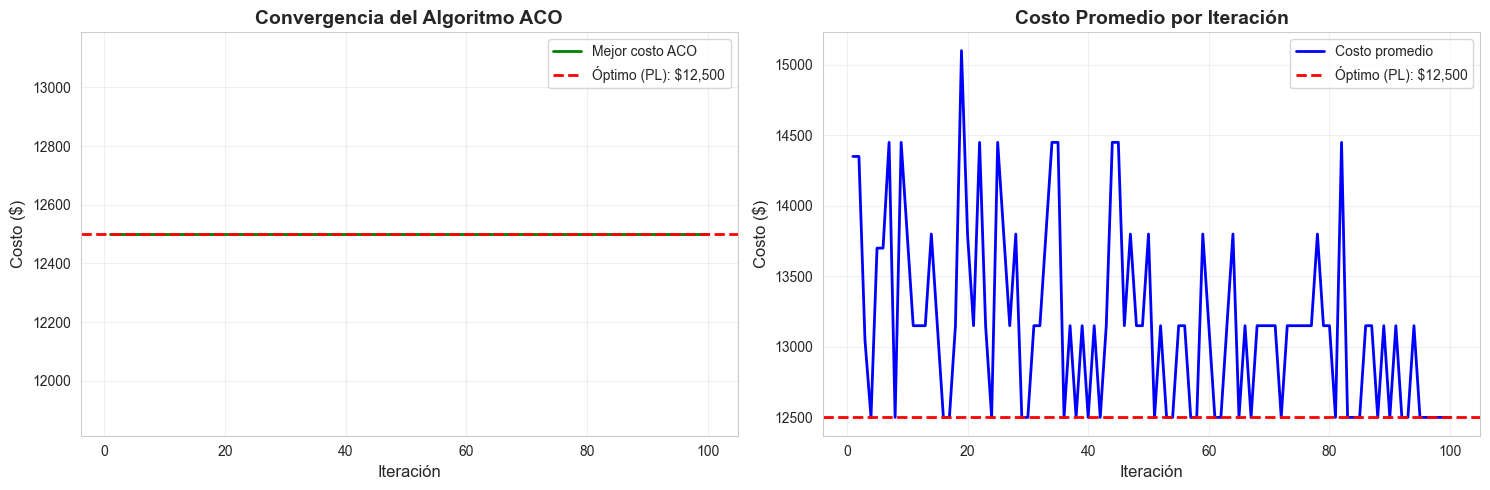

In [24]:
# Gráfica de convergencia ACO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, num_iteraciones + 1), historial_mejor, 
         linewidth=2, color='green', label='Mejor costo ACO')
ax1.axhline(y=costo_pl, color='red', linestyle='--', 
            linewidth=2, label=f'Óptimo (PL): ${costo_pl:,}')
ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Costo ($)', fontsize=12)
ax1.set_title('Convergencia del Algoritmo ACO', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, num_iteraciones + 1), historial_promedio, 
         linewidth=2, color='blue', label='Costo promedio')
ax2.axhline(y=costo_pl, color='red', linestyle='--', 
            linewidth=2, label=f'Óptimo (PL): ${costo_pl:,}')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Costo ($)', fontsize=12)
ax2.set_title('Costo Promedio por Iteración', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

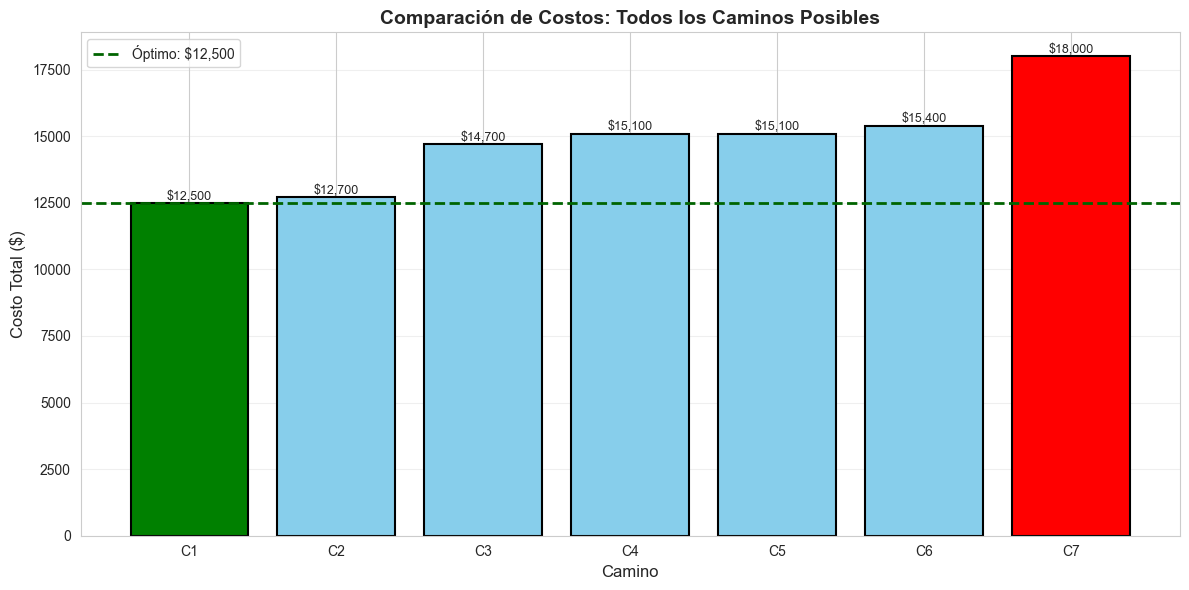


Leyenda de caminos:
  C1: [0, 2, 4]
  C2: [0, 1, 4]
  C3: [0, 3, 4]
  C4: [0, 1, 3, 4]
  C5: [0, 2, 3, 4]
  C6: [0, 1, 2, 4]
  C7: [0, 1, 2, 3, 4]


In [25]:
# Comparación de todos los caminos
plt.figure(figsize=(12, 6))

caminos_labels = [f"C{i+1}" for i in range(len(caminos_con_costos))]
caminos_costos_list = [c for _, c in caminos_con_costos]
colors = ['green' if c == min(caminos_costos_list) 
          else 'red' if c == max(caminos_costos_list) 
          else 'skyblue' for c in caminos_costos_list]

bars = plt.bar(range(len(caminos_costos_list)), caminos_costos_list, 
               color=colors, edgecolor='black', linewidth=1.5)
plt.axhline(y=costo_pl, color='darkgreen', linestyle='--', linewidth=2, 
            label=f'Óptimo: ${costo_pl:,}')
plt.xlabel('Camino', fontsize=12)
plt.ylabel('Costo Total ($)', fontsize=12)
plt.title('Comparación de Costos: Todos los Caminos Posibles', 
          fontsize=14, fontweight='bold')
plt.xticks(range(len(caminos_labels)), caminos_labels)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, costo) in enumerate(zip(bars, caminos_costos_list)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${costo:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nLeyenda de caminos:")
for i, (camino, costo) in enumerate(caminos_con_costos, 1):
    print(f"  C{i}: {camino}")

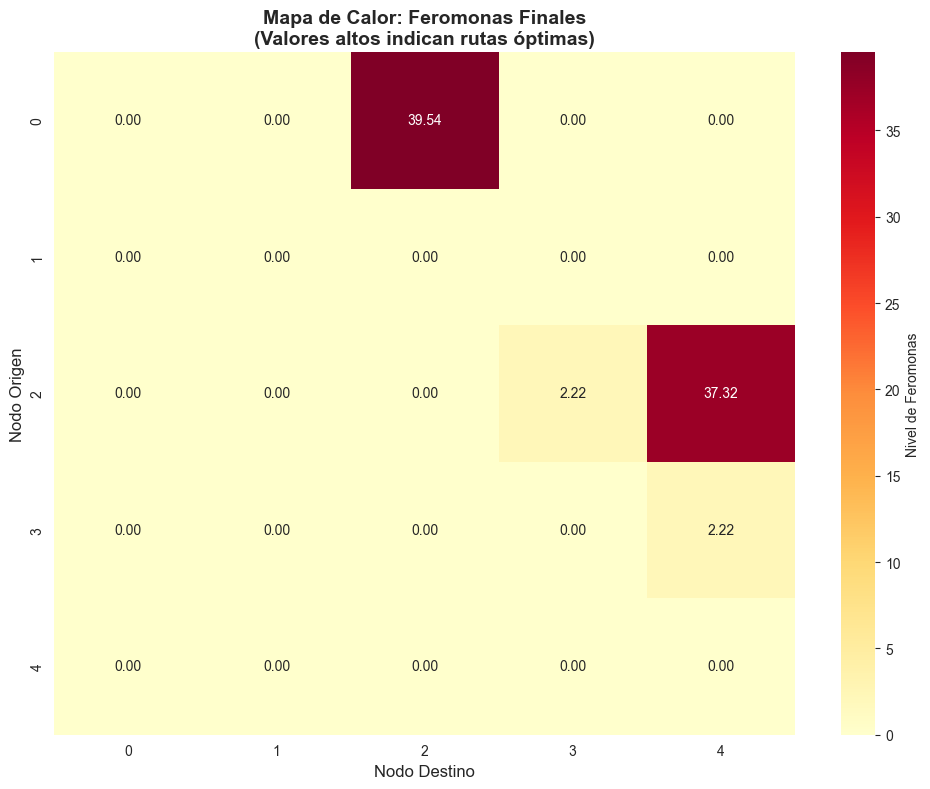

In [26]:
# Mapa de calor de feromonas
matriz_feromonas = np.zeros((5, 5))
for i in feromonas:
    for j in feromonas[i]:
        matriz_feromonas[i][j] = feromonas[i][j]

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_feromonas, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=range(5), yticklabels=range(5),
            cbar_kws={'label': 'Nivel de Feromonas'})
plt.xlabel('Nodo Destino', fontsize=12)
plt.ylabel('Nodo Origen', fontsize=12)
plt.title('Mapa de Calor: Feromonas Finales\n(Valores altos indican rutas óptimas)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análisis y Conclusiones


**Ventajas:**
- Garantiza solución óptima global
- Método determinista (siempre da el mismo resultado)
- Fundamentación matemática sólida
- Eficiente para problemas de tamaño medio
- No requiere ajuste de parámetros
- Bien estudiado y probado

**Desventajas:**
- Requiere formulación matemática clara
- Para problemas muy grandes puede ser lento
- Limitado a problemas con estructura lineal

**Modelo utilizado:**
- Variables binarias para cada arista del grafo
- Restricciones de conservación de flujo
- Función objetivo: minimizar costo total
- Problema de flujo en redes (camino más corto)

#### Ant Colony Optimization

**Ventajas:**
- Flexible y adaptable a diferentes problemas
- No requiere formulación matemática compleja
- Puede escapar de óptimos locales
- Paralelizable (hormigas independientes)
- Útil para problemas NP-difíciles
- Inspiración biológica intuitiva

**Desventajas:**
- No garantiza óptimo global
- Requiere ajuste de parámetros (α, β, ρ, Q)
- Resultados pueden variar entre ejecuciones
- Mayor tiempo de ejecución
- Convergencia no garantizada

**Mecanismo:**
- Construcción probabilística de soluciones
- Depósito y evaporación de feromonas
- Balance entre exploración y explotación
- Refuerzo de buenas soluciones

### Análisis de Feromonas ACO


### Convergencia ACO

**Implicaciones:**
- Parámetros bien ajustados para este problema
- Refuerzo elitista efectivo
- Heurística (1/costo) apropiada

### Cuándo Usar Cada Método

**Use Programación Lineal (Simplex) cuando:**
- Requiera garantía de optimalidad
- El problema tenga estructura lineal clara
- Pueda formular matemáticamente el problema
- El tamaño del problema sea razonable
- Necesite solución determinista

**Use ACO cuando:**
- El problema sea combinatorio complejo
- No exista método exacto eficiente conocido
- Una buena solución sea suficiente
- El problema sea NP-difícil
- Pueda paralelizar la búsqueda
- El problema cambie dinámicamente

### Recomendación para Este Problema

Para el problema de reemplazo de automóviles:

**Método recomendado:** Programación Lineal (Simplex)

**Razones:**
1. Garantiza solución óptima
2. Formulación natural como flujo en redes
3. Eficiente para el tamaño del problema
4. No requiere ajuste de parámetros
5. Resultado determinista y reproducible

**Valor de ACO:**
- Demuestra versatilidad de metaheurísticas
- Útil cuando PL no es aplicable
- Ilustra principios de optimización bio-inspirada

### Conclusión Final

Ambos métodos encontraron la solución óptima ($12,500) con el plan:
- Comprar auto en año 1 y usarlo 2 años
- Comprar auto en año 3 y usarlo 2 años

La Programación Lineal es más apropiada para este problema específico por su garantía de optimalidad y eficiencia. Sin embargo, ACO demuestra ser una alternativa viable que puede aplicarse a problemas más complejos donde métodos exactos no son factibles.